In [28]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [30]:
data_train = datasets.MNIST(root='data', train=True, download=True, transform=transforms.ToTensor()) 
data_test = datasets.MNIST(root='data', train=False, download=True, transform=transforms.ToTensor())    

batch_size = 32
train_dataloader = DataLoader(data_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_dataloader = DataLoader(data_test, batch_size=batch_size, shuffle=False)

# check out a sample
images, labels = next(iter(train_dataloader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")

Image batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])


In [31]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # now in sequential mode
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=4, kernel_size=5, stride=1, padding=1), # output size = np.floor((28 - 5 + 2*1) / 1) + 1 = 26
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # output size = np.floor((26 - 2) / 2) + 1 = 13
            nn.Conv2d(in_channels=4, out_channels=8, kernel_size=5, stride=1, padding=1), # output size = np.floor((13 - 5 + 2*1) / 1) + 1 = 10 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # output size = np.floor((10 - 2) / 2) + 1 = 5
        )
        
        self.fnn = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=8*5*5, out_features=32),
            nn.ReLU(),
            nn.Linear(in_features=32, out_features=10),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.fnn(x)
        return x

model = MNIST_CNN().to(device)
summary(model, input_size=(1, 28, 28), device=device.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 26, 26]             104
              ReLU-2            [-1, 4, 26, 26]               0
         MaxPool2d-3            [-1, 4, 13, 13]               0
            Conv2d-4            [-1, 8, 11, 11]             808
              ReLU-5            [-1, 8, 11, 11]               0
         MaxPool2d-6              [-1, 8, 5, 5]               0
           Flatten-7                  [-1, 200]               0
            Linear-8                   [-1, 32]           6,432
              ReLU-9                   [-1, 32]               0
           Linear-10                   [-1, 10]             330
Total params: 7,674
Trainable params: 7,674
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.03
Estimated Total

In [32]:
def train_one_epoch(model: torch.nn.Module,
                   train_dataloader: torch.utils.data.DataLoader,
                   loss_fn: torch.nn.Module,
                   optimizer: torch.optim.Optimizer,
                   device: torch.device): # Added device
    model.train()
    train_loss = 0.0
    train_accuracy = 0.0
    
    for batch, (X, y) in enumerate(train_dataloader):
        # Move data to the specified device
        X, y = X.to(device), y.to(device)
        
        # Forward pass
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        _, predicted = torch.max(y_pred.data, 1)
        train_accuracy += (predicted == y).sum().item() / y.size(0) 

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return train_loss, train_accuracy

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          device: torch.device, # Added device
          epochs: int):
    
    # Move the entire model to the device once at the start
    model.to(device)
    
    losses_epochs = [] 
    train_accuracy_epochs = []
    test_accuracy_epochs = []

    for epoch in range(epochs):
        # Pass device to the epoch function
        train_loss, train_acc = train_one_epoch(model, train_dataloader, loss_fn, optimizer, device)

        avg_train_loss = train_loss / len(train_dataloader)
        avg_train_acc = train_acc / len(train_dataloader)
        losses_epochs.append(avg_train_loss)
        train_accuracy_epochs.append(avg_train_acc)

        # Evaluate on the test set
        model.eval()
        test_accuracy = 0.0
        with torch.no_grad():
            for X, y in test_dataloader:
                # Move test data to device
                X, y = X.to(device), y.to(device)
                y_pred = model(X)

                _, predicted = torch.max(y_pred.data, 1)
                test_accuracy += (predicted == y).sum().item() / y.size(0)

        avg_test_acc = test_accuracy / len(test_dataloader)
        test_accuracy_epochs.append(avg_test_acc)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, "
              f"Train Accuracy: {avg_train_acc:.4f}, Test Accuracy: {avg_test_acc:.4f}")

    return losses_epochs, train_accuracy_epochs, test_accuracy_epochs

In [33]:
model_mnist = MNIST_CNN()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mnist.parameters(), lr=0.001)

epochs = 7
losses, train_accuracy, test_accuracy = train(model_mnist, train_dataloader, test_dataloader, loss_fn, optimizer, device, epochs)

Epoch [1/7], Train Loss: 0.3098, Train Accuracy: 0.9053, Test Accuracy: 0.9664
Epoch [2/7], Train Loss: 0.0998, Train Accuracy: 0.9691, Test Accuracy: 0.9774
Epoch [3/7], Train Loss: 0.0747, Train Accuracy: 0.9764, Test Accuracy: 0.9821
Epoch [4/7], Train Loss: 0.0616, Train Accuracy: 0.9806, Test Accuracy: 0.9809
Epoch [5/7], Train Loss: 0.0538, Train Accuracy: 0.9829, Test Accuracy: 0.9849
Epoch [6/7], Train Loss: 0.0475, Train Accuracy: 0.9849, Test Accuracy: 0.9856
Epoch [7/7], Train Loss: 0.0427, Train Accuracy: 0.9865, Test Accuracy: 0.9831


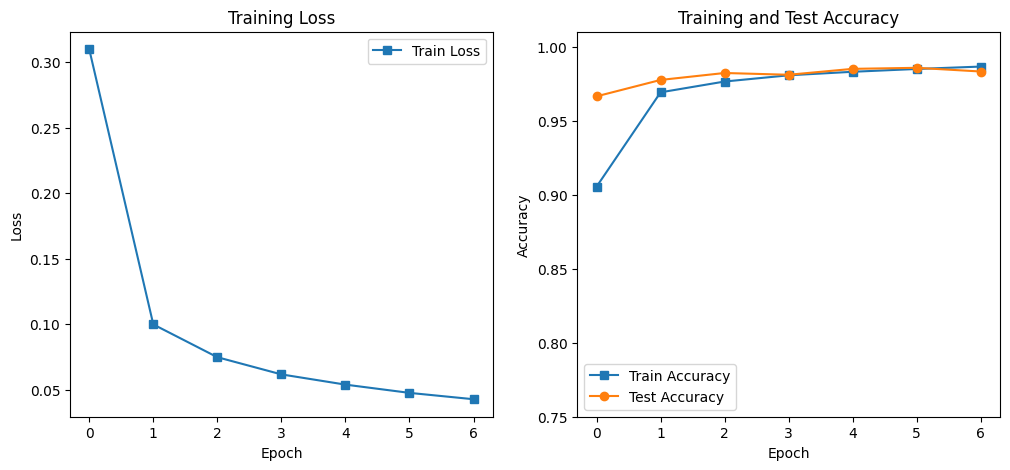

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(losses, "s-", label='Train Loss')
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(train_accuracy, "s-", label='Train Accuracy')
ax[1].plot(test_accuracy, "o-", label='Test Accuracy')
ax[1].set_title("Training and Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0.75, 1.01)
ax[1].legend()

plt.show()

# Transfer learning between MNIST --> FashionMNIST

In [35]:
fashion_data_train = datasets.FashionMNIST(root='data', train=True, download=True, transform=transforms.ToTensor()) 
fashion_data_test = datasets.FashionMNIST(root='data', train=False, download=True, transform=transforms.ToTensor())   

batch_size = 32
fashion_train_dataloader = DataLoader(fashion_data_train, batch_size=batch_size, shuffle=True, drop_last=True)
fashion_test_dataloader = DataLoader(fashion_data_test, batch_size=len(fashion_data_test), shuffle=False)

In [36]:
X, y = next(iter(fashion_test_dataloader))

model_mnist.eval()
with torch.no_grad():
    X, y = next(iter(fashion_test_dataloader))
    y_pred = model_mnist(X.to(device))
    acc = (y_pred.argmax(dim=1) == y.to(device)).float().mean()

print("Accuracy for FMNIST using MNIST trained model=", acc.squeeze(0).item())

Accuracy for FMNIST using MNIST trained model= 0.11819999665021896


In [43]:
# No transfer learning, train just 1 epoch with a new model
model_fashion_1 = MNIST_CNN()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_fashion_1.parameters(), lr=1e-3) # sgd instead of ADAM to see better the difference
epochs = 2

losses, train_accuracy, test_accuracy = train(model_fashion_1, fashion_train_dataloader, fashion_test_dataloader, loss_fn, optimizer, device, epochs)

Epoch [1/2], Train Loss: 2.2908, Train Accuracy: 0.1576, Test Accuracy: 0.2079
Epoch [2/2], Train Loss: 2.0232, Train Accuracy: 0.3191, Test Accuracy: 0.5767


In [42]:
# Transfer learning, train just 1 epoch with pre-trained model
model_fashion_2 = MNIST_CNN()
model_fashion_2.load_state_dict(model_mnist.state_dict()) # load previous model
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_fashion_2.parameters(), lr=1e-3)
epochs = 2

losses, train_accuracy, test_accuracy = train(model_fashion_2, fashion_train_dataloader, fashion_test_dataloader, loss_fn, optimizer, device, epochs)

# we can see how with transfer learning, the model gets a better performance, with ADAM the difference is not that big, since it converges faster

Epoch [1/2], Train Loss: 1.4951, Train Accuracy: 0.4850, Test Accuracy: 0.6510
Epoch [2/2], Train Loss: 0.8508, Train Accuracy: 0.6947, Test Accuracy: 0.7112
